# EDA — HDB feature test split (`hdb_feature_test_20260412.csv`)

Exploratory view of **every column**: types, missing values, ranges, and how one-hot and continuous features behave on the **official test split** (transactions from 2023 onward in this export).

**Default file:** `data/feature_data/02_feature_layer/training/outputs/hdb_feature_test_20260412.csv`  
Change `CSV_PATH` in the setup cell to point at `hdb_feature_train_*.csv` or `hdb_feature_table_*.csv` for comparison.

**Note:** Do not train models on this file if you use it as a held-out test set; this notebook is for inspection only.

In [29]:
%pip install -q pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [30]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

HERE = Path.cwd().resolve()


def _repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "feature_data").is_dir():
            return p
    return start.parent


REPO_ROOT = _repo_root(HERE)
DEFAULT_CSV = (
    REPO_ROOT
    / "data"
    / "feature_data"
    / "02_feature_layer"
    / "training"
    / "outputs"
    / "hdb_feature_test_20260412.csv"
)

# Override if needed: CSV_PATH = Path("/path/to/other_snapshot.csv")
CSV_PATH = DEFAULT_CSV

if not CSV_PATH.is_file():
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
print("REPO_ROOT:", REPO_ROOT)
print("CSV_PATH:", CSV_PATH)
print("Shape:", df.shape[0], "rows ×", df.shape[1], "columns")

REPO_ROOT: /Users/bhuvesh/Documents/PropertyLens
CSV_PATH: /Users/bhuvesh/Documents/PropertyLens/data/feature_data/02_feature_layer/training/outputs/hdb_feature_test_20260412.csv
Shape: 82809 rows × 86 columns


## 1 — Column groups

The export mixes **identifiers**, **target**, **numeric engineered features**, and **one-hot** columns (`town_*`, `flat_type_*`, `flat_model_*`).

In [31]:
ID_COLS = [c for c in df.columns if c == "address_key"]
TARGET = "resale_price"
TOWN_OH = sorted(c for c in df.columns if c.startswith("town_"))
FLAT_TYPE_OH = sorted(c for c in df.columns if c.startswith("flat_type_"))
FLAT_MODEL_OH = sorted(c for c in df.columns if c.startswith("flat_model_"))

ONE_HOT = TOWN_OH + FLAT_TYPE_OH + FLAT_MODEL_OH
NUMERIC_RAW = [
    c
    for c in df.columns
    if c not in ID_COLS + ONE_HOT and pd.api.types.is_numeric_dtype(df[c])
]
# Features used in models = numeric columns except target (plus one-hots are numeric 0/1)
FEATURE_NUM = [c for c in NUMERIC_RAW if c != TARGET]

print("Identifiers:", ID_COLS)
print("Target:", TARGET)
print("One-hot town:", len(TOWN_OH), "| flat_type:", len(FLAT_TYPE_OH), "| flat_model:", len(FLAT_MODEL_OH))
print("Numeric non-one-hot columns:", len(NUMERIC_RAW), "(includes target)")

Identifiers: ['address_key']
Target: resale_price
One-hot town: 26 | flat_type: 7 | flat_model: 21
Numeric non-one-hot columns: 31 (includes target)


## 2 — Per-column profile (all columns)

One row per column: missing rate, uniqueness, and distribution stats where applicable. For **one-hot** columns, `positive_rate` is the fraction of rows with value `1`.

In [32]:
def profile_column(s: pd.Series) -> dict:
    n = len(s)
    nn = s.notna().sum()
    out = {
        "dtype": str(s.dtype),
        "non_null": int(nn),
        "missing_pct": round(100 * (n - nn) / n, 4) if n else 0.0,
        "n_unique": int(s.nunique(dropna=True)),
    }
    if pd.api.types.is_numeric_dtype(s) and nn > 0:
        sn = s.dropna()
        # pandas quantile/median fail on numpy bool; treat as 0/1 float
        if pd.api.types.is_bool_dtype(sn.dtype):
            sn = sn.astype(np.float64)
        out["min"] = float(sn.min())
        out["q25"] = float(sn.quantile(0.25))
        out["median"] = float(sn.median())
        out["q75"] = float(sn.quantile(0.75))
        out["max"] = float(sn.max())
        out["mean"] = float(sn.mean())
        out["std"] = float(sn.std())
        u = set(sn.unique())
        if u <= {0, 0.0, 1, 1.0} or u <= {0, 1}:
            out["positive_rate_pct"] = round(100 * float((sn == 1).mean()), 4)
    elif s.dtype == object and nn > 0:
        out["sample_values"] = " | ".join(str(x) for x in s.dropna().head(3).tolist())
    return out


profile = pd.DataFrame({c: profile_column(df[c]) for c in df.columns}).T
profile.insert(0, "group", "")
for col in profile.index:
    if col in ID_COLS:
        profile.loc[col, "group"] = "id"
    elif col == TARGET:
        profile.loc[col, "group"] = "target"
    elif col.startswith("town_"):
        profile.loc[col, "group"] = "onehot_town"
    elif col.startswith("flat_type_"):
        profile.loc[col, "group"] = "onehot_flat_type"
    elif col.startswith("flat_model_"):
        profile.loc[col, "group"] = "onehot_flat_model"
    else:
        profile.loc[col, "group"] = "numeric_engineered"

profile = profile.reset_index().rename(columns={"index": "column"})
profile = profile.sort_values(["group", "column"]).set_index("column")

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
profile

,group,dtype,non_null,missing_pct,n_unique,min,q25,median,q75,max,mean,std,positive_rate_pct
column,,,,,,,,,,,,,
address_key,id,str,82809,0.0,9421,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
biz_childcare_rented,numeric_engineered,float64,82809,0.0,2,55.0,55.0,61.0,61.0,61.0,59.135348,2.776883,NaN
biz_commercial_rented_total,numeric_engineered,float64,82809,0.0,2,432.0,432.0,432.0,568.0,568.0,474.265454,62.94268,NaN
biz_community_rented,numeric_engineered,float64,82809,0.0,2,12.0,12.0,12.0,19.0,19.0,14.175428,3.239697,NaN
biz_eldercare_rented,numeric_engineered,float64,82809,0.0,2,8.0,8.0,13.0,13.0,13.0,11.446123,2.314069,NaN
biz_offices_rented,numeric_engineered,float64,82809,0.0,2,90.0,90.0,90.0,127.0,127.0,101.49869,17.124112,NaN
biz_shops_eating_rented,numeric_engineered,float64,82809,0.0,2,304.0,304.0,304.0,384.0,384.0,328.862032,37.025106,NaN
biz_social_rented_total,numeric_engineered,float64,82809,0.0,2,90.0,90.0,90.0,94.0,94.0,91.243102,1.851255,NaN
dist_to_foodcourt_m,numeric_engineered,float64,82809,0.0,9419,34.864206,489.172028,828.241215,1247.916494,2919.296952,936.466227,570.522434,NaN


### Export the profile table (optional)

Writes a CSV next to this notebook under `training/outputs/eda_profiles/` for diffing across snapshots.

In [33]:
out_dir = REPO_ROOT / "data" / "feature_data" / "02_feature_layer" / "training" / "outputs" / "eda_profiles"
out_dir.mkdir(parents=True, exist_ok=True)
stem = CSV_PATH.stem
profile_out = out_dir / f"{stem}_column_profile.csv"
profile.reset_index().to_csv(profile_out, index=False)
print("Wrote:", profile_out)

Wrote: /Users/bhuvesh/Documents/PropertyLens/data/feature_data/02_feature_layer/training/outputs/eda_profiles/hdb_feature_test_20260412_column_profile.csv


## 3 — Target and transaction year

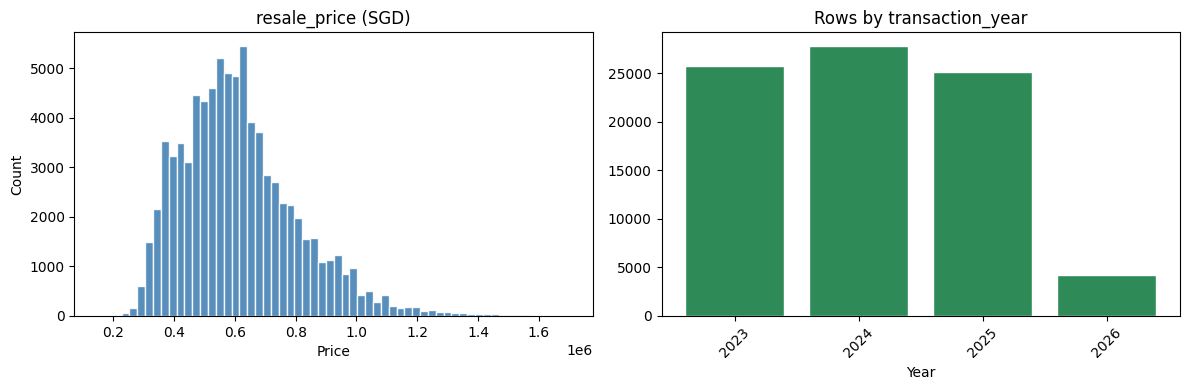

count    8.280900e+04
mean     6.142609e+05
std      1.928710e+05
min      1.500000e+05
25%      4.780000e+05
50%      5.900000e+05
75%      7.180000e+05
max      1.700000e+06
Name: resale_price, dtype: float64
transaction_year: 2023 – 2026


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[TARGET].dropna(), bins=60, color="steelblue", edgecolor="white", alpha=0.9)
axes[0].set_title("resale_price (SGD)")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Count")

yr = df["transaction_year"].dropna().astype(int)
vc = yr.value_counts().sort_index()
axes[1].bar(vc.index.astype(str), vc.values, color="seagreen", edgecolor="white")
axes[1].set_title("Rows by transaction_year")
axes[1].set_xlabel("Year")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(df[TARGET].describe())
print("transaction_year:", yr.min(), "–", yr.max())

## 4 — Engineered numeric features (histograms)

Excludes target and one-hot columns. Log-scale option for heavy-tailed distances.

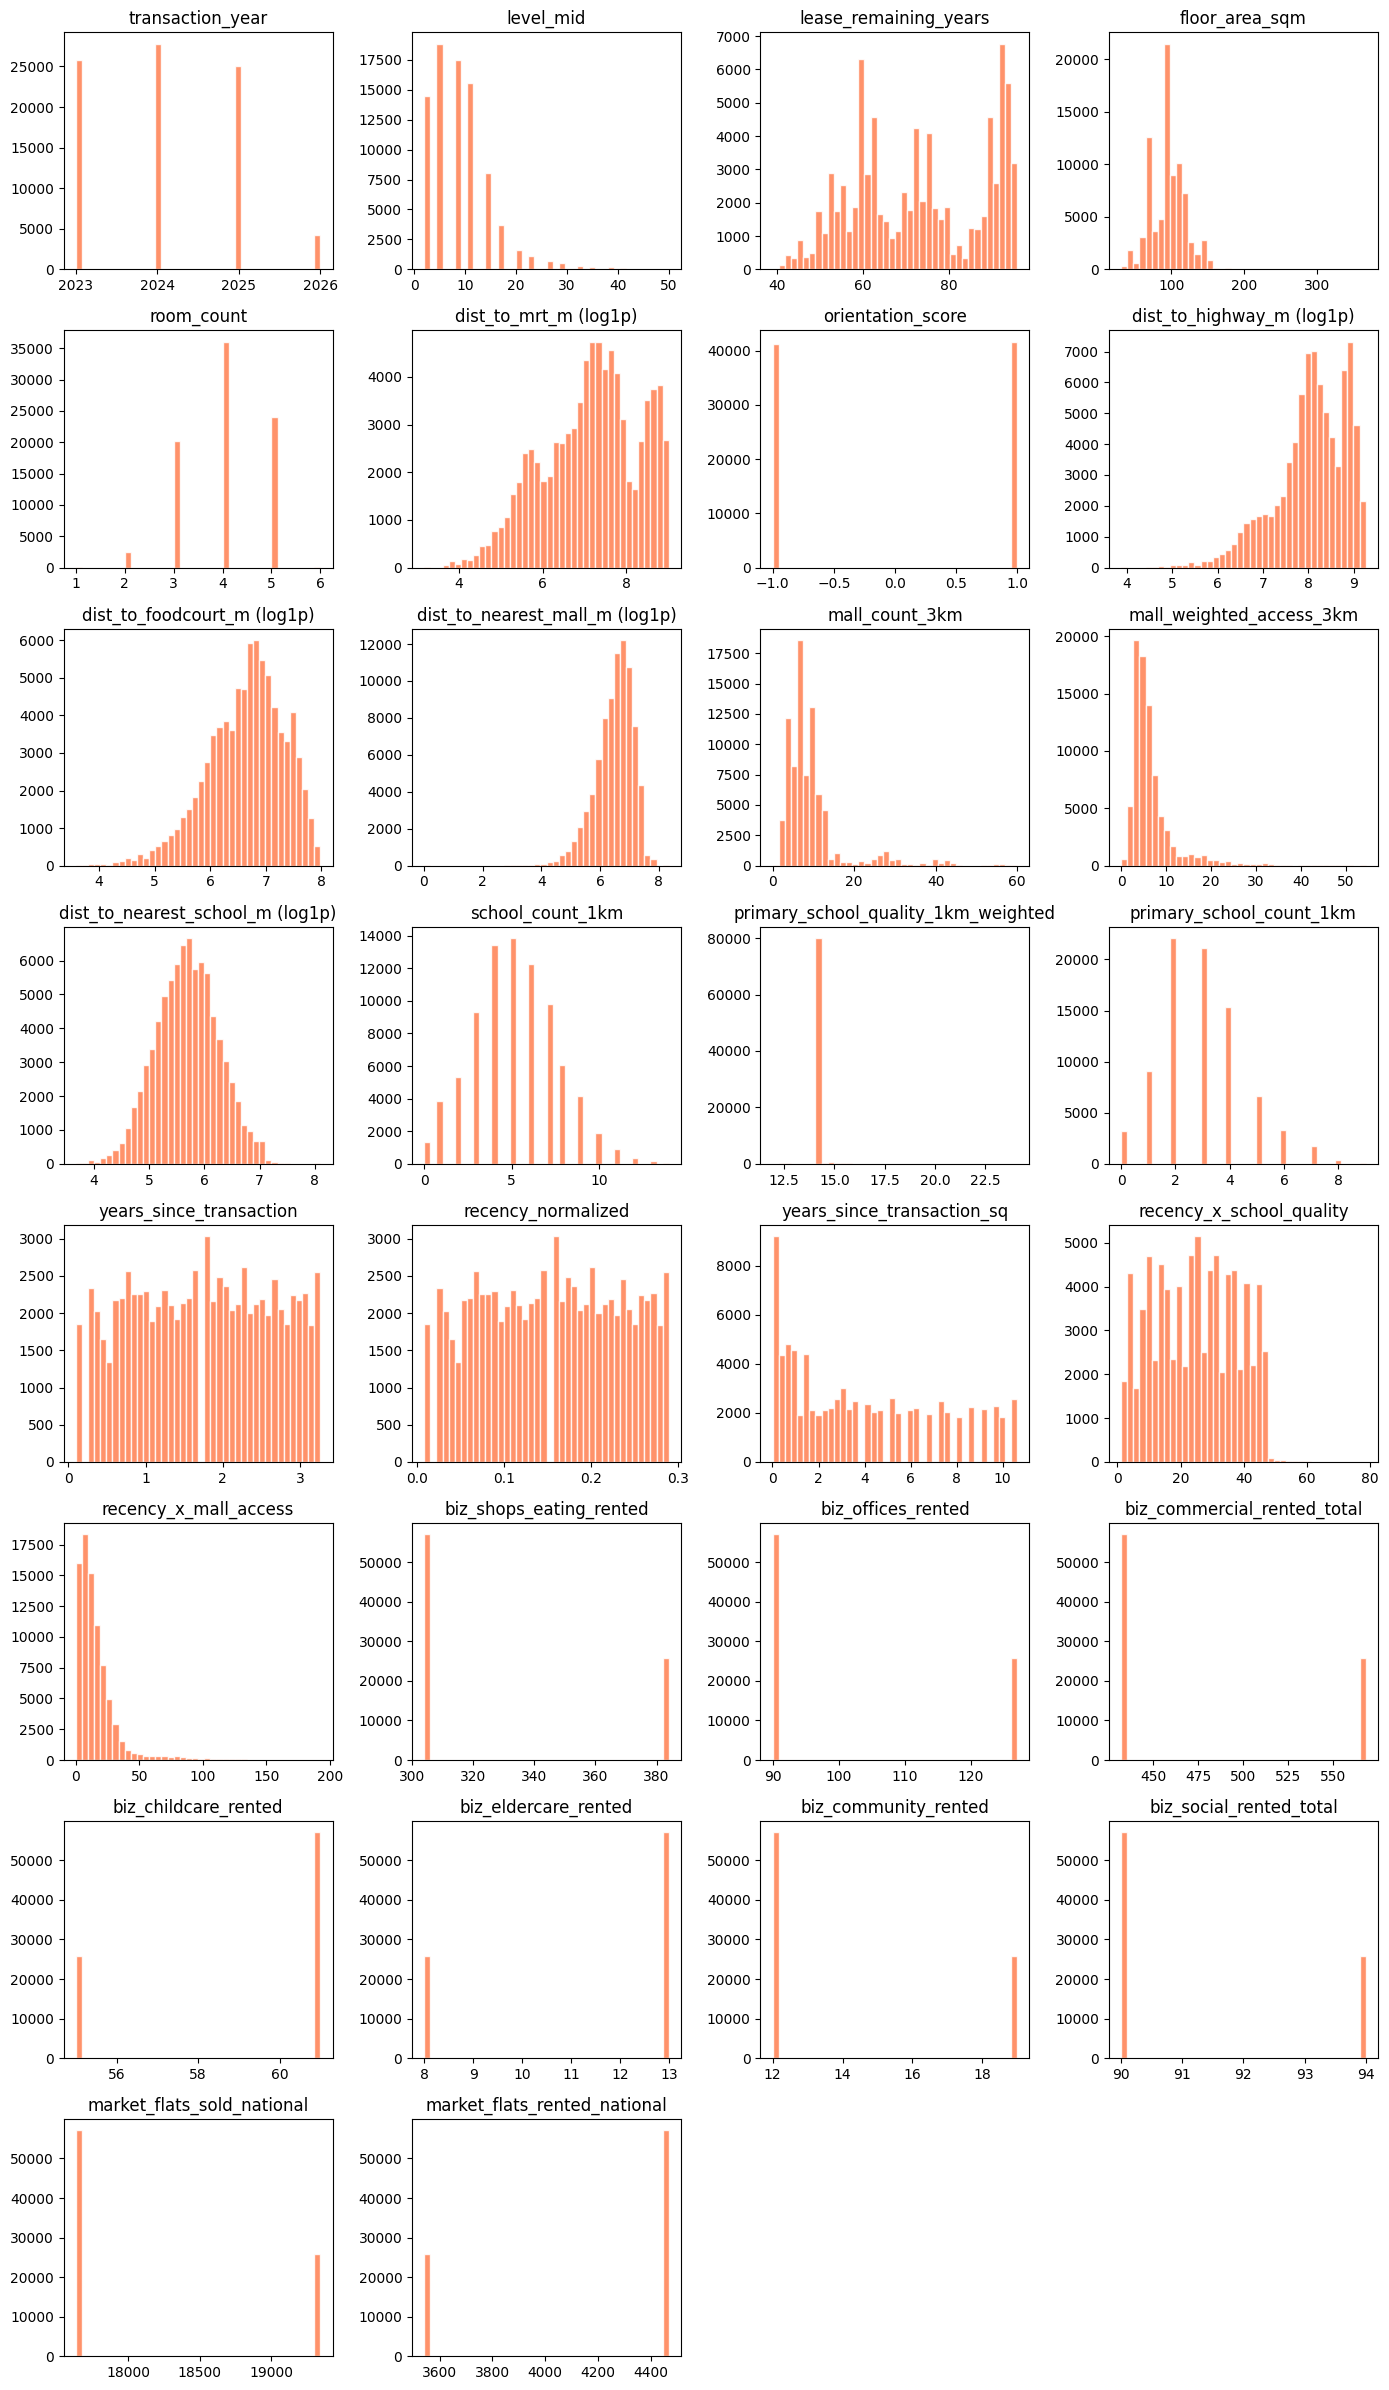

In [35]:
cols = [c for c in FEATURE_NUM if c != "transaction_year"]
cols = ["transaction_year"] + cols  # year first
n = len(cols)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, cols):
    s = df[col].dropna()
    if col.startswith("dist_") and (s > 0).all():
        s = np.log1p(s)
        ax.set_title(f"{col} (log1p)")
    else:
        ax.set_title(col)
    ax.hist(s, bins=40, color="coral", edgecolor="white", alpha=0.85)
for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

## 5 — One-hot prevalence

For each group, **mean(column)** = share of rows where that category is active (exactly one town / flat_type / flat_model should be 1 per row if encoding is consistent).

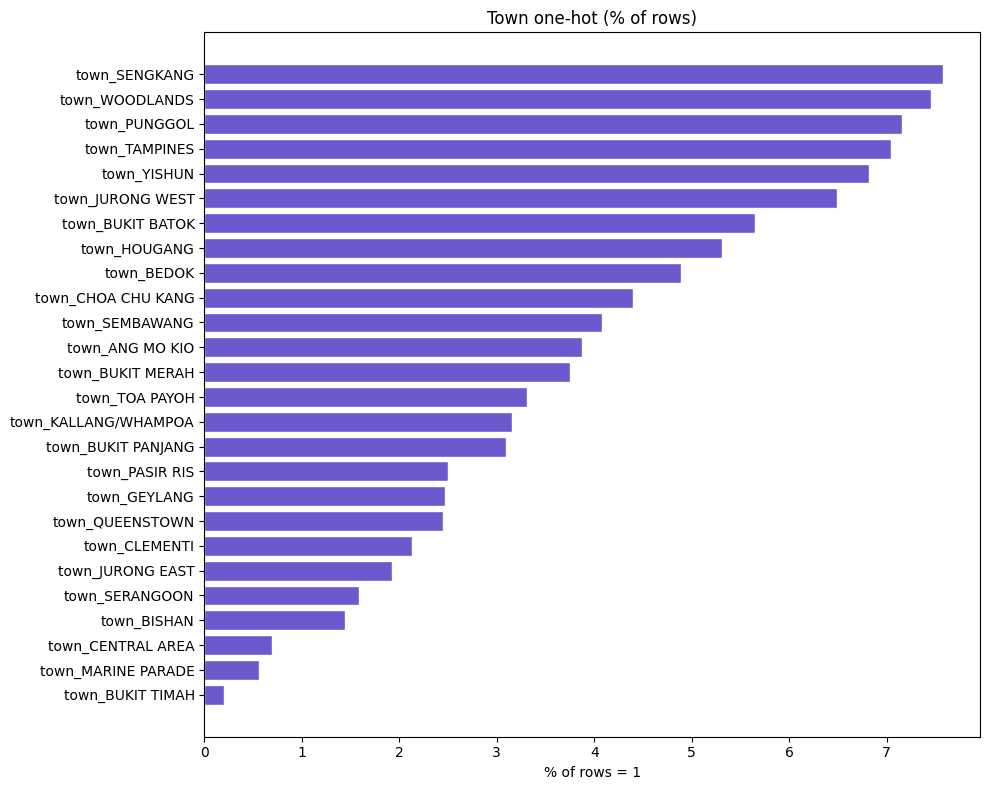

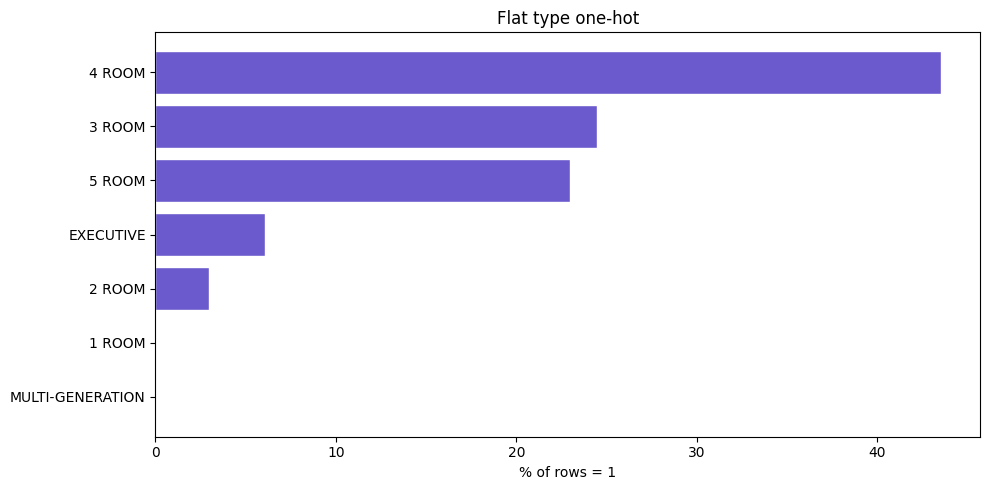

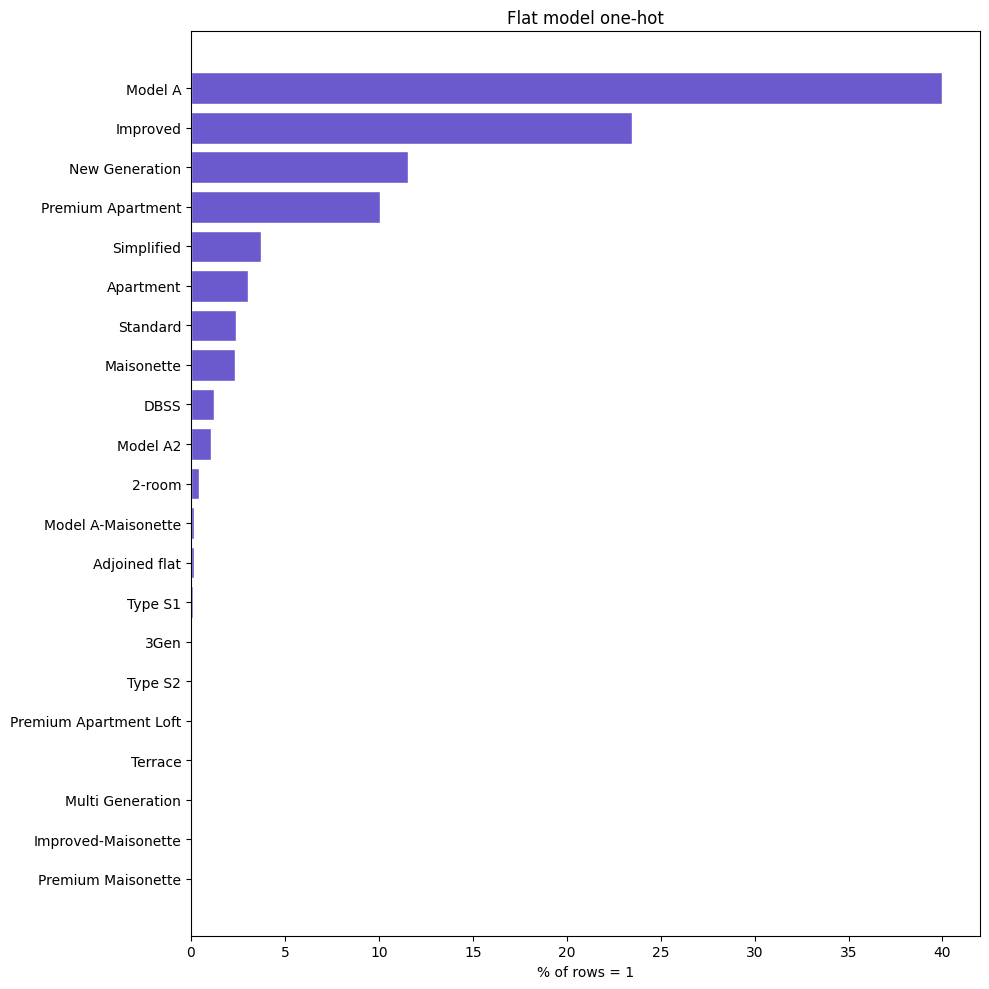

In [36]:
def plot_onehot_prevalence(columns: list[str], title: str, figsize=(10, 5)):
    if not columns:
        print("No columns for", title)
        return
    prev = df[columns].mean().sort_values(ascending=True)
    labels = [c.split("_", 2)[-1] if c.count("_") >= 2 else c for c in prev.index]
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(labels, 100 * prev.values, color="slateblue", edgecolor="white")
    ax.set_xlabel("% of rows = 1")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return prev


pt = plot_onehot_prevalence(TOWN_OH, "Town one-hot (% of rows)", figsize=(10, 8))
pft = plot_onehot_prevalence(FLAT_TYPE_OH, "Flat type one-hot")
pfm = plot_onehot_prevalence(FLAT_MODEL_OH, "Flat model one-hot", figsize=(10, 10))

In [37]:
# Sanity: each row should have exactly one '1' per one-hot family
for name, cols in [
    ("town", TOWN_OH),
    ("flat_type", FLAT_TYPE_OH),
    ("flat_model", FLAT_MODEL_OH),
]:
    row_sums = df[cols].sum(axis=1).astype(float)
    bad = (~np.isclose(row_sums, 1.0)).sum()
    print(f"{name}: rows where sum(one-hots) not ≈ 1: {bad} / {len(df)}")

town: rows where sum(one-hots) not ≈ 1: 0 / 82809
flat_type: rows where sum(one-hots) not ≈ 1: 0 / 82809
flat_model: rows where sum(one-hots) not ≈ 1: 0 / 82809


## 6 — Correlation with `resale_price`

Pearson correlation on **numeric** columns (one-hots included). Interpret one-hot correlations as association with higher/lower price vs omitted baseline.

Top 25 by |correlation| with resale_price:
floor_area_sqm                  0.657696
room_count                      0.653174
flat_type_3 ROOM               -0.509207
lease_remaining_years           0.361084
level_mid                       0.361009
flat_type_EXECUTIVE             0.347074
flat_type_5 ROOM                0.339511
flat_model_New Generation      -0.299434
flat_model_Maisonette           0.251702
flat_type_2 ROOM               -0.242685
flat_model_Apartment            0.225417
mall_count_3km                  0.208101
mall_weighted_access_3km        0.188147
flat_model_DBSS                 0.177652
recency_normalized             -0.177391
years_since_transaction        -0.177391
years_since_transaction_sq     -0.175488
recency_x_school_quality       -0.174542
transaction_year                0.167794
market_flats_sold_national     -0.147713
biz_social_rented_total        -0.147713
biz_commercial_rented_total    -0.147713
market_flats_rented_national    0.147713
biz_shops_eati

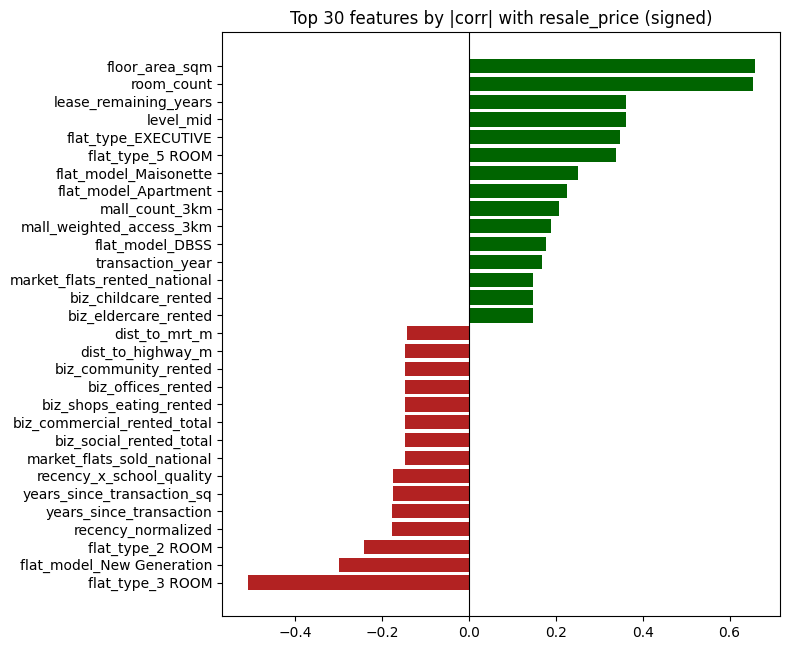

In [38]:
num_for_corr = [c for c in df.columns if c != "address_key" and pd.api.types.is_numeric_dtype(df[c])]
corr = df[num_for_corr].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("Top 25 by |correlation| with resale_price:")
print(corr.head(25).to_string())

top_k = min(30, len(corr))
tail = corr.head(top_k).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, max(4, top_k * 0.22)))
ax.barh(tail.index.astype(str), tail.values, color=np.where(tail.values >= 0, "darkgreen", "firebrick"))
ax.axvline(0, color="black", lw=0.8)
ax.set_title(f"Top {top_k} features by |corr| with resale_price (signed)")
plt.tight_layout()
plt.show()

## 7 — Spot-check: `address_key` sample

Identifier format for joining / lookup in other pipelines.

In [39]:
print("n_unique address_key:", df["address_key"].nunique(), "| rows:", len(df))
dup = df["address_key"].duplicated().sum()
print("duplicate address_key rows:", int(dup))
print(df[["address_key", TARGET, "transaction_year"]].head(10).to_string(index=False))

n_unique address_key: 9421 | rows: 82809
duplicate address_key rows: 73388
          address_key  resale_price  transaction_year
406 ANG MO KIO AVE 10      267000.0              2023
 314 ANG MO KIO AVE 3      280000.0              2023
 314 ANG MO KIO AVE 3      282000.0              2023
 170 ANG MO KIO AVE 4      289800.0              2023
 323 ANG MO KIO AVE 3      300000.0              2023
 151 ANG MO KIO AVE 5      324500.0              2023
 213 ANG MO KIO AVE 3      338000.0              2023
 603 ANG MO KIO AVE 5      338888.0              2023
474 ANG MO KIO AVE 10      341888.0              2023
541 ANG MO KIO AVE 10      345000.0              2023


## 8 — Concrete evidence: suspect block vs hybrid test MAPE

This section **re-runs the same pipeline** as `notebooks/03_ml_layer_hybrid/02_hybrid_ensemble.ipynb`: **K-Means** (fit on train only, structural `CLUSTER_COLS` — **no** suspect columns), **global** Ridge + XGB + LGB + RF with **Ridge meta-stack** and **MAPE-tuned blend**, then **per-cluster** stacks with **12-draw XGB random search** on val MAPE.

**Temporal split:** train `transaction_year` **< 2024**, val **== 2024**, test **≥ 2025**. **Model features** = numeric columns except `address_key` and `resale_price` (same as `build_feature_columns` in the hybrid notebook).

**Suspect block** = `DROP_NEW_SCHEMA_FEATURES` in that notebook (14 columns: recency, `biz_*`, national market series).

1. **Structure on the test window** — `n_unique` and **|corr(., transaction_year)|** for suspect columns.
2. **Hybrid ablation** — Full hybrid **with** vs **without** suspect columns in `FEATURE_COLS`. **Cluster assignments match** between runs (clustering does not use the suspect block). Metrics use **sklearn** `mean_absolute_percentage_error` × 100, same as the hybrid notebook.

Requires `hdb_feature_table_<same_date>.csv` next to `CSV_PATH`. **Heavy** (~two full hybrid trains). Run after setup + `%pip` cell.


In [40]:
%pip install -q numpy pandas scipy scikit-learn xgboost lightgbm matplotlib


Note: you may need to restart the kernel to use updated packages.


Rows — train: 205930 | val: 27808 | test: 29266
Features — with suspect: 84 | without: 70
\n=== Suspect columns on TEST (y >= 2025) ===
                      column  n_unique_test  abs_corr_tx_year_test
     years_since_transaction             15               0.630514
          recency_normalized             15               0.630514
    recency_x_school_quality            924               0.628667
  years_since_transaction_sq             15               0.501888
       recency_x_mall_access            687               0.272832
     biz_shops_eating_rented              1                    NaN
          biz_offices_rented              1                    NaN
 biz_commercial_rented_total              1                    NaN
        biz_childcare_rented              1                    NaN
        biz_eldercare_rented              1                    NaN
        biz_community_rented              1                    NaN
     biz_social_rented_total              1                 

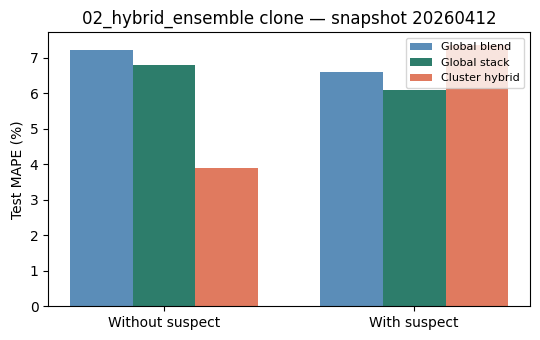

In [41]:
# Hybrid ablation — logic aligned with notebooks/03_ml_layer_hybrid/02_hybrid_ensemble.ipynb
import warnings
from scipy.optimize import minimize

import xgboost as xgb
import lightgbm as lgb
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

TARGET = "resale_price"
YEAR_COL = "transaction_year"
N_CLUSTERS = 4
MIN_CLUSTER_TRAIN = 5000
META_COLS = ["address_key"]
DROP_FROM_FEATURES = [TARGET] + META_COLS

CLUSTER_COLS = [
    "level_mid",
    "lease_remaining_years",
    "floor_area_sqm",
    "room_count",
    "dist_to_mrt_m",
    "orientation_score",
    "dist_to_highway_m",
    "dist_to_foodcourt_m",
    "dist_to_nearest_mall_m",
    "mall_count_3km",
    "mall_weighted_access_3km",
    "dist_to_nearest_school_m",
    "school_count_1km",
    "primary_school_quality_1km_weighted",
    "primary_school_top_quality_1km",
]

SUSPECT_FEATURES = (
    "years_since_transaction",
    "recency_normalized",
    "years_since_transaction_sq",
    "recency_x_school_quality",
    "recency_x_mall_access",
    "biz_shops_eating_rented",
    "biz_offices_rented",
    "biz_commercial_rented_total",
    "biz_childcare_rented",
    "biz_eldercare_rented",
    "biz_community_rented",
    "biz_social_rented_total",
    "market_flats_sold_national",
    "market_flats_rented_national",
)


def build_feature_columns(d):
    return [
        c
        for c in d.columns
        if c not in DROP_FROM_FEATURES and pd.api.types.is_numeric_dtype(d[c])
    ]


def evaluate(name, y_true, y_pred):
    return {
        "model": name,
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "mape": float(mean_absolute_percentage_error(y_true, y_pred) * 100),
        "r2": float(r2_score(y_true, y_pred)),
    }


def run_hybrid_pipeline(df_in, feature_cols, rng):
    '''Mirror 02_hybrid_ensemble: global stack/blend + per-cluster stacks.'''
    train_mask = df_in[YEAR_COL] < 2024
    val_mask = df_in[YEAR_COL] == 2024
    test_mask = df_in[YEAR_COL] >= 2025

    X_all = df_in[feature_cols].fillna(0).astype(float)
    y_all = df_in[TARGET].astype(float)

    X_train = X_all.loc[train_mask].values
    y_train = y_all.loc[train_mask].values
    X_val = X_all.loc[val_mask].values
    y_val = y_all.loc[val_mask].values
    X_test = X_all.loc[test_mask].values
    y_test = y_all.loc[test_mask].values

    cc = [c for c in CLUSTER_COLS if c in df_in.columns]
    Xc = df_in[cc].fillna(0).astype(float).values
    cluster_scaler = StandardScaler().fit(Xc[train_mask.values])
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
    kmeans.fit(cluster_scaler.transform(Xc[train_mask.values]))
    cluster_all = kmeans.predict(cluster_scaler.transform(Xc))

    df = df_in.copy()
    df["cluster_id"] = cluster_all

    cl_train = df.loc[train_mask, "cluster_id"].values
    cl_val = df.loc[val_mask, "cluster_id"].values
    cl_test = df.loc[test_mask, "cluster_id"].values

    best_a, best_m = None, np.inf
    for alpha in np.logspace(-1, 4, 25):
        ridge = Pipeline([("sc", StandardScaler()), ("r", Ridge(alpha=alpha, random_state=42))])
        ridge.fit(X_train, y_train)
        p = ridge.predict(X_val)
        m = mean_absolute_percentage_error(y_val, p) * 100
        if m < best_m:
            best_m, best_a = m, alpha

    global_ridge = Pipeline([("sc", StandardScaler()), ("r", Ridge(alpha=best_a, random_state=42))])
    global_ridge.fit(X_train, y_train)

    global_xgb = xgb.XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_alpha=0.1,
        reg_lambda=1.0,
        n_jobs=-1,
        random_state=42,
        early_stopping_rounds=50,
        eval_metric="rmse",
        verbosity=0,
    )
    global_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    global_lgb = lgb.LGBMRegressor(
        n_estimators=600,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    global_lgb.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )

    global_rf = RandomForestRegressor(
        n_estimators=120, max_depth=16, min_samples_leaf=5, random_state=42, n_jobs=-1
    )
    global_rf.fit(X_train, y_train)

    def collect_preds(m_xgb, m_lgb, m_rf, m_ridge, Xtr, Xv, Xt):
        pr_v = m_ridge.predict(Xv)
        px_v = m_xgb.predict(Xv)
        pl_v = m_lgb.predict(Xv)
        pf_v = m_rf.predict(Xv)
        pr_t = m_ridge.predict(Xt)
        px_t = m_xgb.predict(Xt)
        pl_t = m_lgb.predict(Xt)
        pf_t = m_rf.predict(Xt)
        return (
            np.column_stack([pr_v, px_v, pl_v, pf_v]),
            np.column_stack([pr_t, px_t, pl_t, pf_t]),
        )

    P_val_g, P_test_g = collect_preds(global_xgb, global_lgb, global_rf, global_ridge, X_train, X_val, X_test)

    meta_global = Ridge(alpha=1.0, random_state=42)
    meta_global.fit(P_val_g, y_val)
    stack_val_g = meta_global.predict(P_val_g)
    stack_test_g = meta_global.predict(P_test_g)

    def blend_mape(w, P, y):
        w = np.array(w)
        pred = P @ w
        return mean_absolute_percentage_error(y, pred) * 100

    best = None
    for _ in range(40):
        x0 = rng.random(4) * 2
        res = minimize(
            lambda w: blend_mape(w, P_val_g, y_val), x0=x0, method="Nelder-Mead", options={"maxiter": 3000}
        )
        if best is None or res.fun < best.fun:
            best = res
    w_blend = best.x if best is not None else np.ones(4) / 4
    blend_test_g = P_test_g @ w_blend
    blend_val_g = P_val_g @ w_blend

    tv_mask = np.logical_or(train_mask.values, val_mask.values)
    hybrid_test = np.zeros(len(y_test))

    for k in range(N_CLUSTERS):
        tr_idx = np.where(cl_train == k)[0]
        va_idx = np.where(cl_val == k)[0]
        te_idx = np.where(cl_test == k)[0]
        n_tr = len(tr_idx)

        if n_tr < MIN_CLUSTER_TRAIN:
            if len(te_idx):
                hybrid_test[te_idx] = blend_test_g[te_idx]
            continue
        if len(va_idx) == 0:
            if len(te_idx):
                hybrid_test[te_idx] = blend_test_g[te_idx]
            continue

        Xtr_k, ytr_k = X_train[tr_idx], y_train[tr_idx]
        Xva_k, yva_k = X_val[va_idx], y_val[va_idx]
        pos_tv = np.where((df["cluster_id"].values == k) & tv_mask)[0]
        Xtv_k = X_all.values[pos_tv]
        ytv_k = y_all.values[pos_tv]
        if len(Xtv_k) == 0:
            if len(te_idx):
                hybrid_test[te_idx] = blend_test_g[te_idx]
            continue

        best_xgb = None
        best_mape = np.inf
        for _ in range(12):
            md_ = int(rng.choice([6, 8, 10]))
            lr = float(rng.choice([0.03, 0.04, 0.05]))
            mcw = int(rng.choice([3, 5, 7]))
            est = int(rng.choice([400, 600, 800]))
            mdl = xgb.XGBRegressor(
                n_estimators=est,
                learning_rate=lr,
                max_depth=md_,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=mcw,
                reg_alpha=0.1,
                reg_lambda=1.0,
                n_jobs=-1,
                random_state=42,
                early_stopping_rounds=40,
                eval_metric="rmse",
                verbosity=0,
            )
            mdl.fit(Xtr_k, ytr_k, eval_set=[(Xva_k, yva_k)], verbose=False)
            pv = mdl.predict(Xva_k)
            mape = mean_absolute_percentage_error(yva_k, pv) * 100
            if mape < best_mape:
                best_mape, best_xgb = mape, mdl

        if best_xgb is None:
            best_xgb = xgb.XGBRegressor(
                n_estimators=600,
                learning_rate=0.05,
                max_depth=8,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=5,
                reg_alpha=0.1,
                reg_lambda=1.0,
                n_jobs=-1,
                random_state=42,
                early_stopping_rounds=40,
                eval_metric="rmse",
                verbosity=0,
            )
            best_xgb.fit(Xtr_k, ytr_k, eval_set=[(Xva_k, yva_k)], verbose=False)

        bx = best_xgb
        ridge_k = Pipeline([("sc", StandardScaler()), ("r", Ridge(alpha=10.0, random_state=42))])
        ridge_k.fit(Xtr_k, ytr_k)
        lgb_k = lgb.LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            verbose=-1,
        )
        lgb_k.fit(
            Xtr_k,
            ytr_k,
            eval_set=[(Xva_k, yva_k)],
            callbacks=[lgb.early_stopping(40, verbose=False)],
        )
        rf_k = RandomForestRegressor(
            n_estimators=100, max_depth=14, min_samples_leaf=8, random_state=42, n_jobs=-1
        )
        rf_k.fit(Xtr_k, ytr_k)

        Pr_v = np.column_stack(
            [ridge_k.predict(Xva_k), bx.predict(Xva_k), lgb_k.predict(Xva_k), rf_k.predict(Xva_k)]
        )
        meta_k = Ridge(alpha=1.0, random_state=42)
        meta_k.fit(Pr_v, yva_k)

        ridge_k2 = Pipeline([("sc", StandardScaler()), ("r", Ridge(alpha=10.0, random_state=42))])
        ridge_k2.fit(Xtv_k, ytv_k)
        bx2 = xgb.XGBRegressor(
            n_estimators=bx.n_estimators,
            learning_rate=bx.learning_rate,
            max_depth=bx.max_depth,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=bx.min_child_weight,
            reg_alpha=0.1,
            reg_lambda=1.0,
            n_jobs=-1,
            random_state=42,
            verbosity=0,
        )
        bx2.fit(Xtv_k, ytv_k)
        lgb_k2 = lgb.LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            verbose=-1,
        )
        lgb_k2.fit(Xtv_k, ytv_k)
        rf_k2 = RandomForestRegressor(
            n_estimators=100, max_depth=14, min_samples_leaf=8, random_state=42, n_jobs=-1
        )
        rf_k2.fit(Xtv_k, ytv_k)

        if len(te_idx):
            Xt_k = X_test[te_idx]
            Pt_k = np.column_stack(
                [ridge_k2.predict(Xt_k), bx2.predict(Xt_k), lgb_k2.predict(Xt_k), rf_k2.predict(Xt_k)]
            )
            hybrid_test[te_idx] = meta_k.predict(Pt_k)

    return {
        "n_features": len(feature_cols),
        "test_blend": evaluate("Global blend", y_test, blend_test_g),
        "test_stack": evaluate("Global stack", y_test, stack_test_g),
        "test_hybrid": evaluate("Cluster hybrid", y_test, hybrid_test),
        "val_blend": evaluate("Global blend", y_val, blend_val_g),
        "val_stack": evaluate("Global stack", y_val, stack_val_g),
    }


OUT_DIR = REPO_ROOT / "data" / "feature_data" / "02_feature_layer" / "training" / "outputs" / "eda_profiles"
OUT_DIR.mkdir(parents=True, exist_ok=True)

snap = CSV_PATH.stem.split("_")[-1]
feat_dir = CSV_PATH.parent
full_path = feat_dir / f"hdb_feature_table_{snap}.csv"
if not full_path.is_file():
    raise FileNotFoundError(f"Need full table for ablation: {full_path}")

df0 = pd.read_csv(full_path)
suspect_present = [c for c in SUSPECT_FEATURES if c in df0.columns]
df_drop = df0.drop(columns=suspect_present) if suspect_present else df0.copy()

feats_with = build_feature_columns(df0)
feats_without = build_feature_columns(df_drop)

train_m = df0[YEAR_COL] < 2024
val_m = df0[YEAR_COL] == 2024
test_m = df0[YEAR_COL] >= 2025
print(
    "Rows — train:", int(train_m.sum()),
    "| val:", int(val_m.sum()),
    "| test:", int(test_m.sum()),
)
print("Features — with suspect:", len(feats_with), "| without:", len(feats_without))

# Structural diagnostics (test window)
yr = df0.loc[test_m, YEAR_COL].astype(float)
rows = []
for c in suspect_present:
    s = df0.loc[test_m, c].astype(float)
    nu = int(s.nunique())
    ca = float(np.abs(s.corr(yr))) if s.std() > 0 else float("nan")
    rows.append({"column": c, "n_unique_test": nu, "abs_corr_tx_year_test": ca})
diag = pd.DataFrame(rows).sort_values("abs_corr_tx_year_test", ascending=False)
print("\\n=== Suspect columns on TEST (y >= 2025) ===")
print(diag.to_string(index=False))
diag.to_csv(OUT_DIR / f"ablation_suspect_structure_{snap}.csv", index=False)

rng_a = np.random.default_rng(42)
rng_b = np.random.default_rng(42)
print("\\n=== Running hybrid WITHOUT suspect block (same RNG seed as WITH) ===")
r_wo = run_hybrid_pipeline(df_drop, feats_without, rng_a)
print("=== Running hybrid WITH suspect block ===")
r_wi = run_hybrid_pipeline(df0, feats_with, rng_b)


def row(label, r):
    return {
        "variant": label,
        "n_features": r["n_features"],
        "val_mape_blend": r["val_blend"]["mape"],
        "val_mape_stack": r["val_stack"]["mape"],
        "test_mape_blend": r["test_blend"]["mape"],
        "test_mape_stack": r["test_stack"]["mape"],
        "test_mape_hybrid": r["test_hybrid"]["mape"],
    }


summary = pd.DataFrame([row("Without suspect", r_wo), row("With suspect", r_wi)])
print("\\n=== Hybrid ablation summary (sklearn MAPE %) ===")
print(summary.to_string(index=False))
summary.to_csv(OUT_DIR / f"ablation_hybrid_summary_{snap}.csv", index=False)
print("\\nWrote:", OUT_DIR / f"ablation_hybrid_summary_{snap}.csv")

d = r_wo["test_hybrid"]["mape"] - r_wi["test_hybrid"]["mape"]
print(
    "\\nΔ test MAPE cluster hybrid (without − with suspect): "
    f"{d:+.4f} pp — "
    f"({'better without' if d < 0 else 'better with'}) suspect block"
)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
x = np.arange(2)
w = 0.25
ax.bar(x - w, summary["test_mape_blend"], w, label="Global blend", color="#5b8db8")
ax.bar(x, summary["test_mape_stack"], w, label="Global stack", color="#2d7d6b")
ax.bar(x + w, summary["test_mape_hybrid"], w, label="Cluster hybrid", color="#e07a5f")
ax.set_xticks(x)
ax.set_xticklabels(summary["variant"])
ax.set_ylabel("Test MAPE (%)")
ax.legend(loc="upper right", fontsize=8)
ax.set_title(f"02_hybrid_ensemble clone — snapshot {snap}")
plt.tight_layout()
plt.show()
